# Advanced ML Bootcamp
## Week 02 Assignment - Multiple Linear Regression with EDA

### 1. Loading and Preprocessing Data

In [1]:
import pandas as pd

df = pd.read_excel("data/ENB2012_data.xlsx")

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [3]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [4]:
# Remove categorical-like coded variables
df_quant = df.drop(columns=["X6", "X8"])

# X6 and X8 are not suitable as quantitative variables because their integer values are category labels,
# so differences such as 5 - 2 do not represent a meaningful numeric distance or order.

In [5]:
# Build a valid feature matrix for predicting Heating Load (Y1)
X = df_quant.drop(columns=["Y1", "Y2"])
y = df_quant["Y1"] # Target

In [6]:
# Inspecting the data
print("Cleaned-data shape:", df_quant.shape)
print("\nData types:")
print(df_quant.dtypes)
print("\nMissing values:")
print(df_quant.isna().sum())

Cleaned-data shape: (768, 8)

Data types:
X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X7    float64
Y1    float64
Y2    float64
dtype: object

Missing values:
X1    0
X2    0
X3    0
X4    0
X5    0
X7    0
Y1    0
Y2    0
dtype: int64


In [7]:
print("\nPredictor shape:", X.shape)
print("Target shape:", y.shape)


Predictor shape: (768, 6)
Target shape: (768,)


### 2. Exploratory Data Analysis

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("deep")

In [9]:
X.describe()

,X1,X2,X3,X4,X5,X7
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,0.234375
std,0.105777,88.086116,43.626481,45.165950,1.75114,0.133221
min,0.620000,514.500000,245.000000,110.250000,3.50000,0.000000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,0.100000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,0.250000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,0.400000
max,0.980000,808.500000,416.500000,220.500000,7.00000,0.400000


#### Univariate analysis

Univariate analysis studies one variable at a time. The goal is to describe a variable's centre, spread, shape, repeated values, and any unusually distant observations.

##### Distribution and Skew

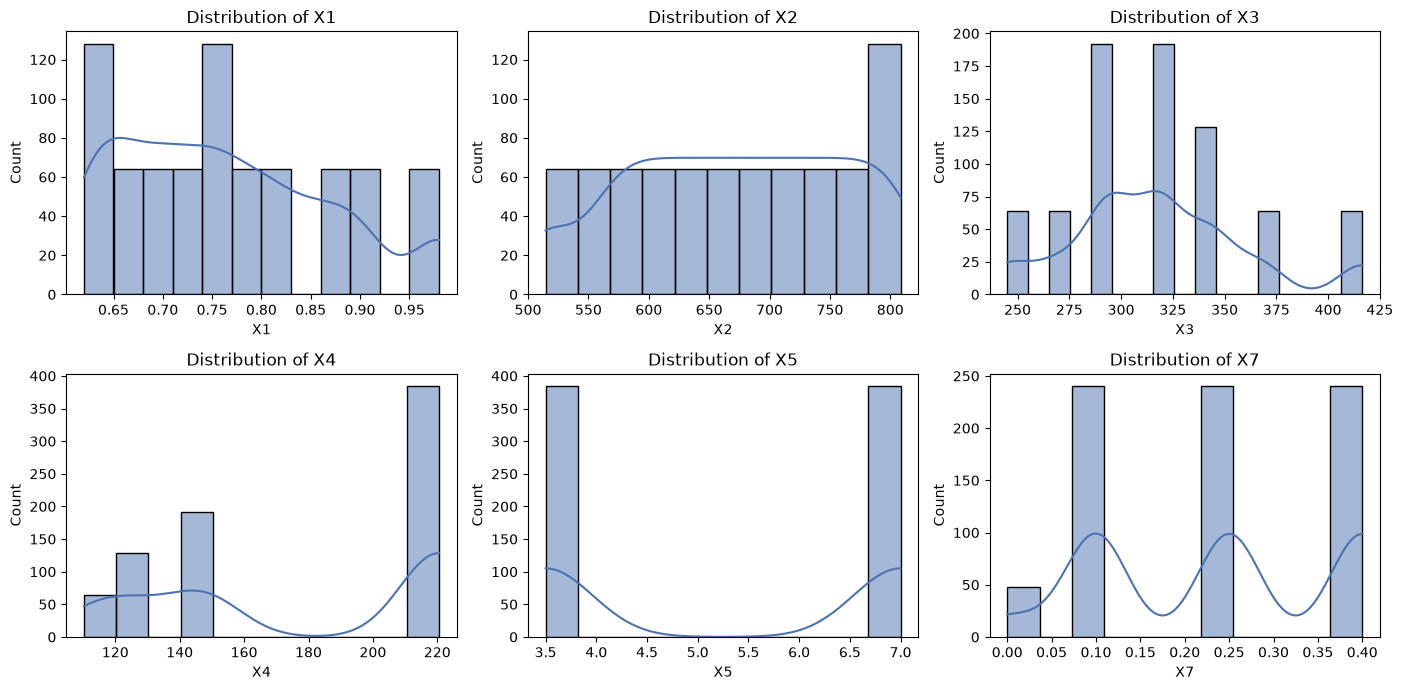

In [10]:
# Histograms to check the distribution of each variable
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(X):
    sns.histplot(X[c], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {c}')
plt.tight_layout()
plt.show()
    

##### Spread and Outliers

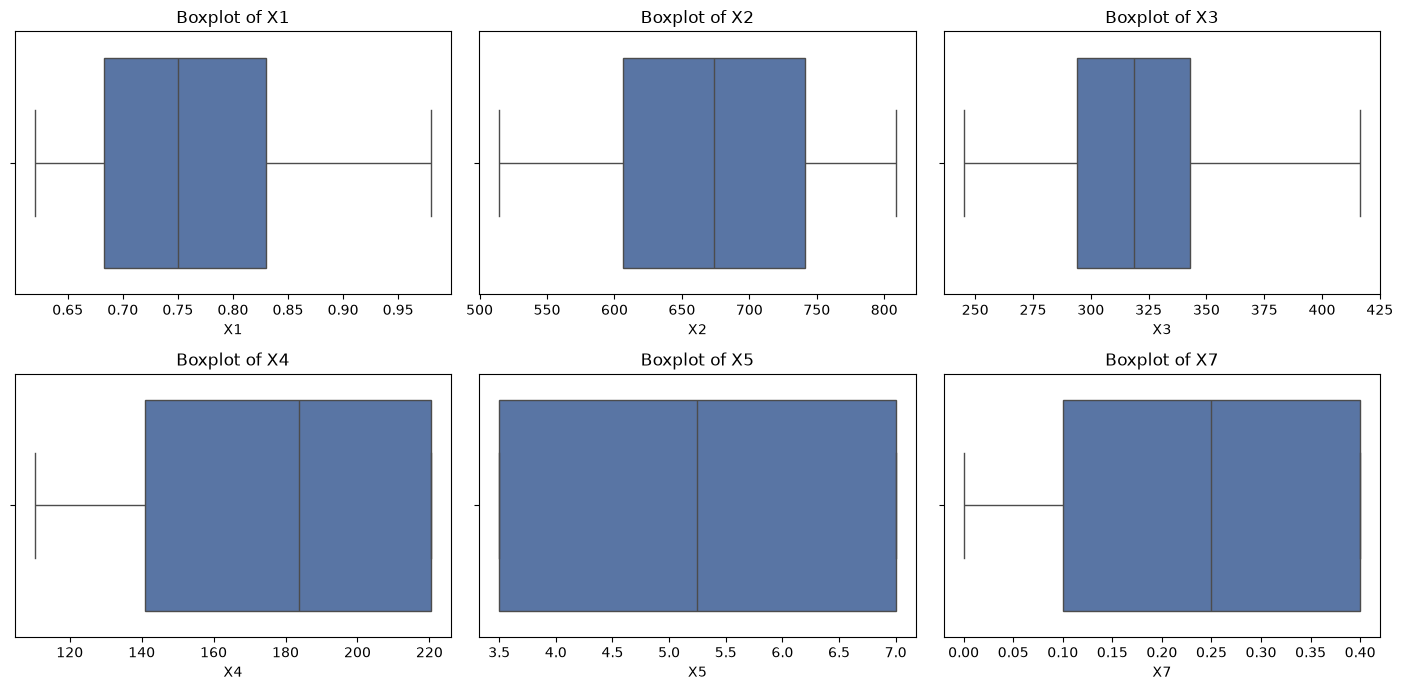

In [11]:
# Boxplots to check for outliers in each variable
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(X):
    sns.boxplot(x=X[c], ax=axes[i])
    axes[i].set_title(f'Boxplot of {c}')
plt.tight_layout()
plt.show()

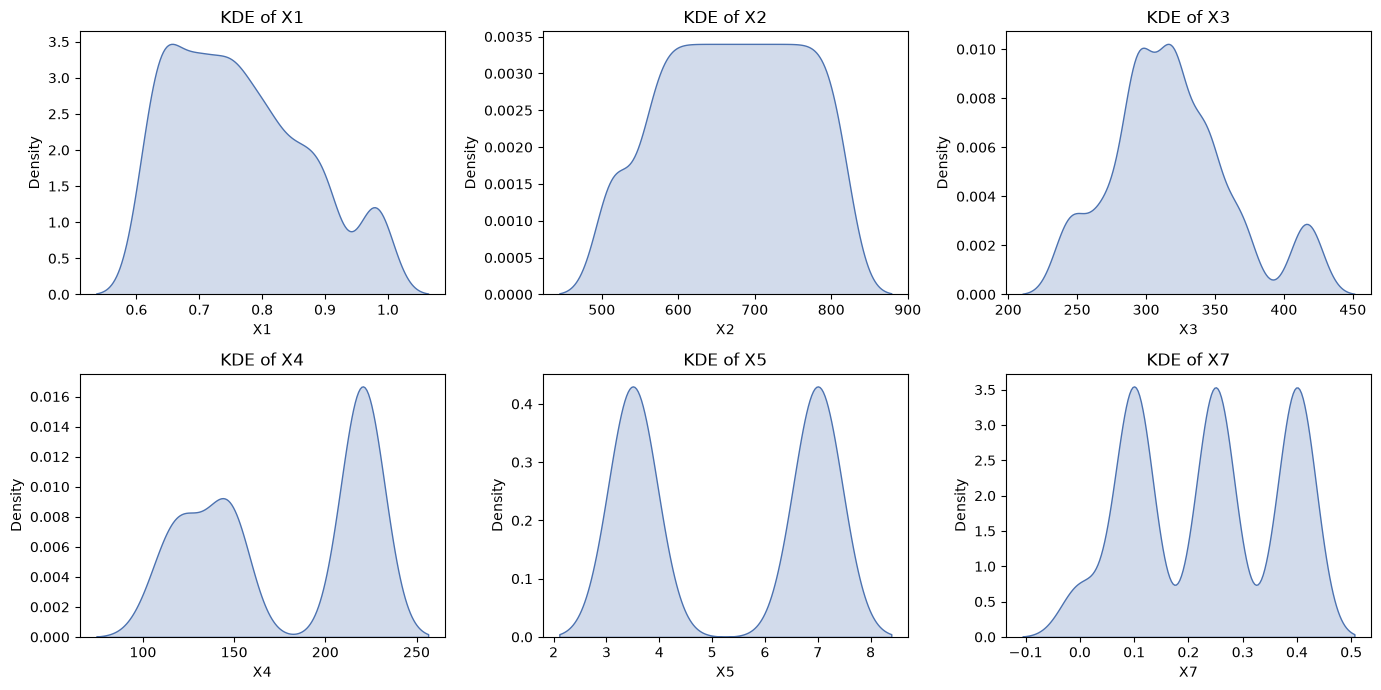

In [12]:
# KDE density plots to check the distribution of each variable
# A KDE (Kernel Density Estimate) is a smoothed estimate of a variable’s distribution.
# Unlike a histogram, it does not depend on bin boundaries.

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(X):
    sns.kdeplot(X[c], ax=axes[i], fill=True)
    axes[i].set_title(f'KDE of {c}')
plt.tight_layout()
plt.show()

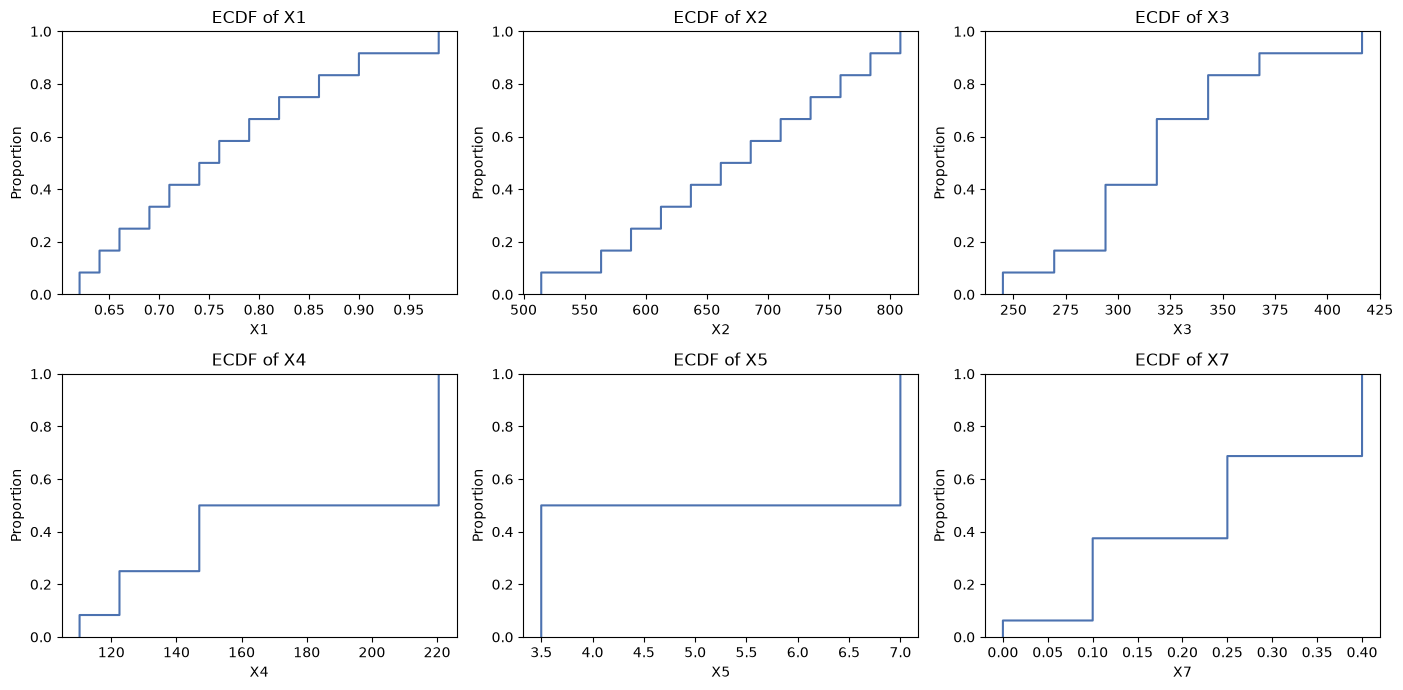

In [13]:
# ECDF plots to check the distribution of each variable
# An ECDF (Empirical Cumulative Distribution Function) is a plot of the proportion of observations less than or equal to a given value.
# It is a non-parametric estimate of the cumulative distribution function (CDF) of a variable.

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(X.columns):
    sns.ecdfplot(X[c], ax=axes[i])
    axes[i].set_title(f'ECDF of {c}')
plt.tight_layout()
plt.show()

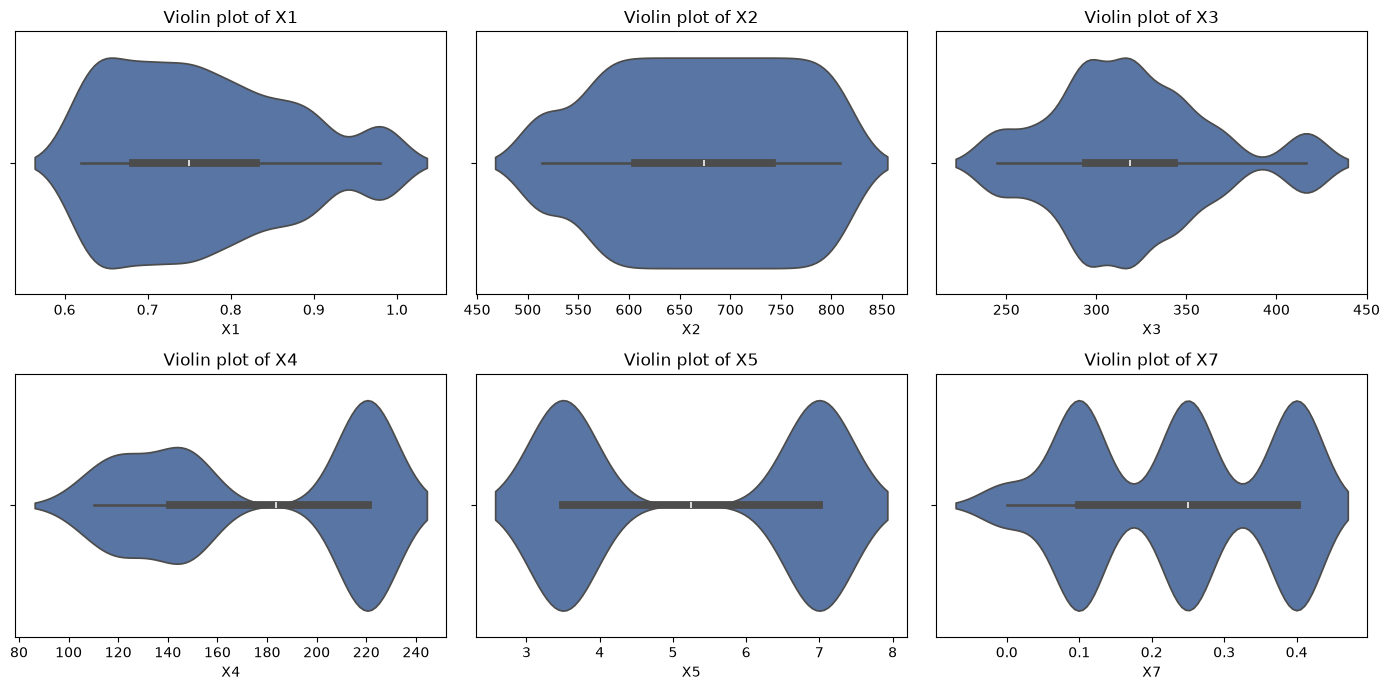

In [14]:
# Violin plots to check the distribution of each variable
# A violin plot is a combination of a boxplot and a KDE plot. It shows the distribution of a variable, its median, and its interquartile range (IQR).

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(X):
    sns.violinplot(x=X[c], ax=axes[i])
    axes[i].set_title(f'Violin plot of {c}')
plt.tight_layout()
plt.show()

#### Bivariate analysis

Bivariate analysis examines the relationship between two variables. Here, the question is:
> “How does each quantitative building attribute relate to Heating Load (Y1)?”

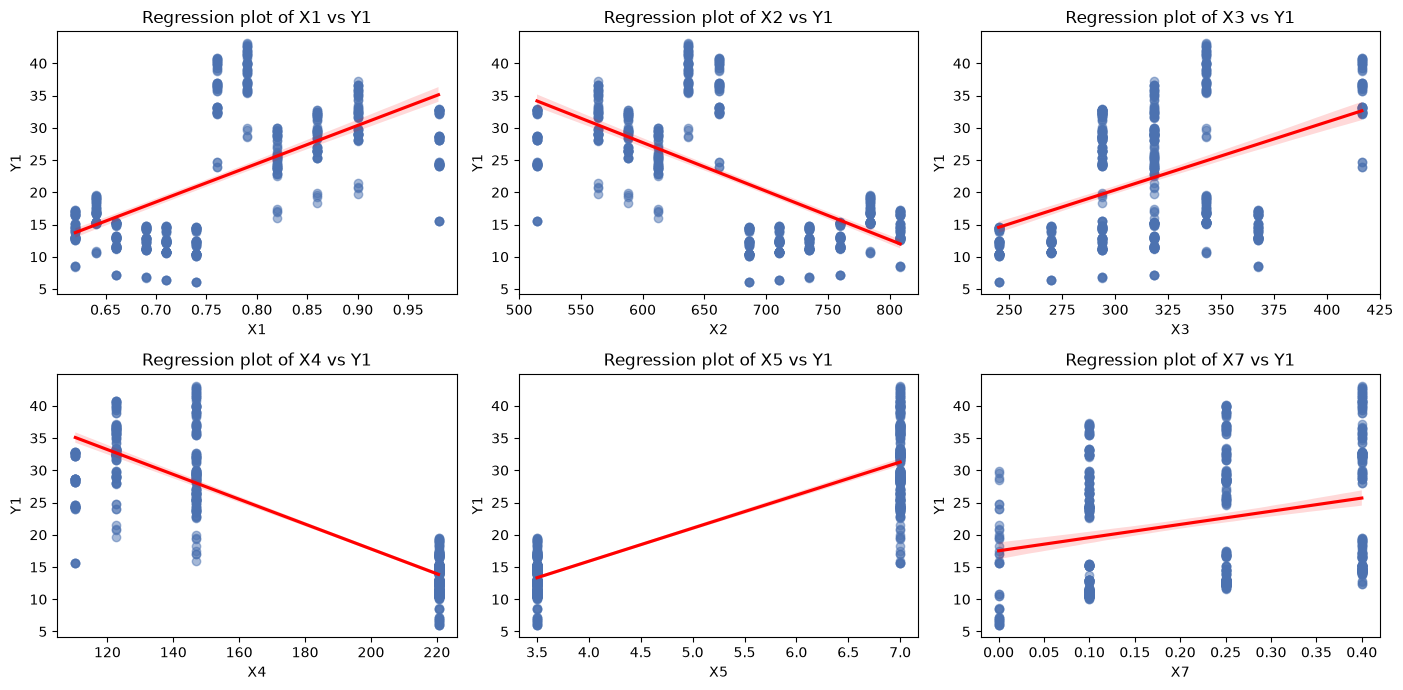

In [15]:
# Regression plots to check the relationship between each predictor and the target variable
# A regression plot is a scatter plot with a fitted regression line. It shows the relationship between a predictor and the target variable, as well as the strength and direction of that relationship.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(X):
    sns.regplot(x=X[c], y=y, ax=axes[i], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[i].set_title(f'Regression plot of {c} vs Y1')
plt.tight_layout()
plt.show()

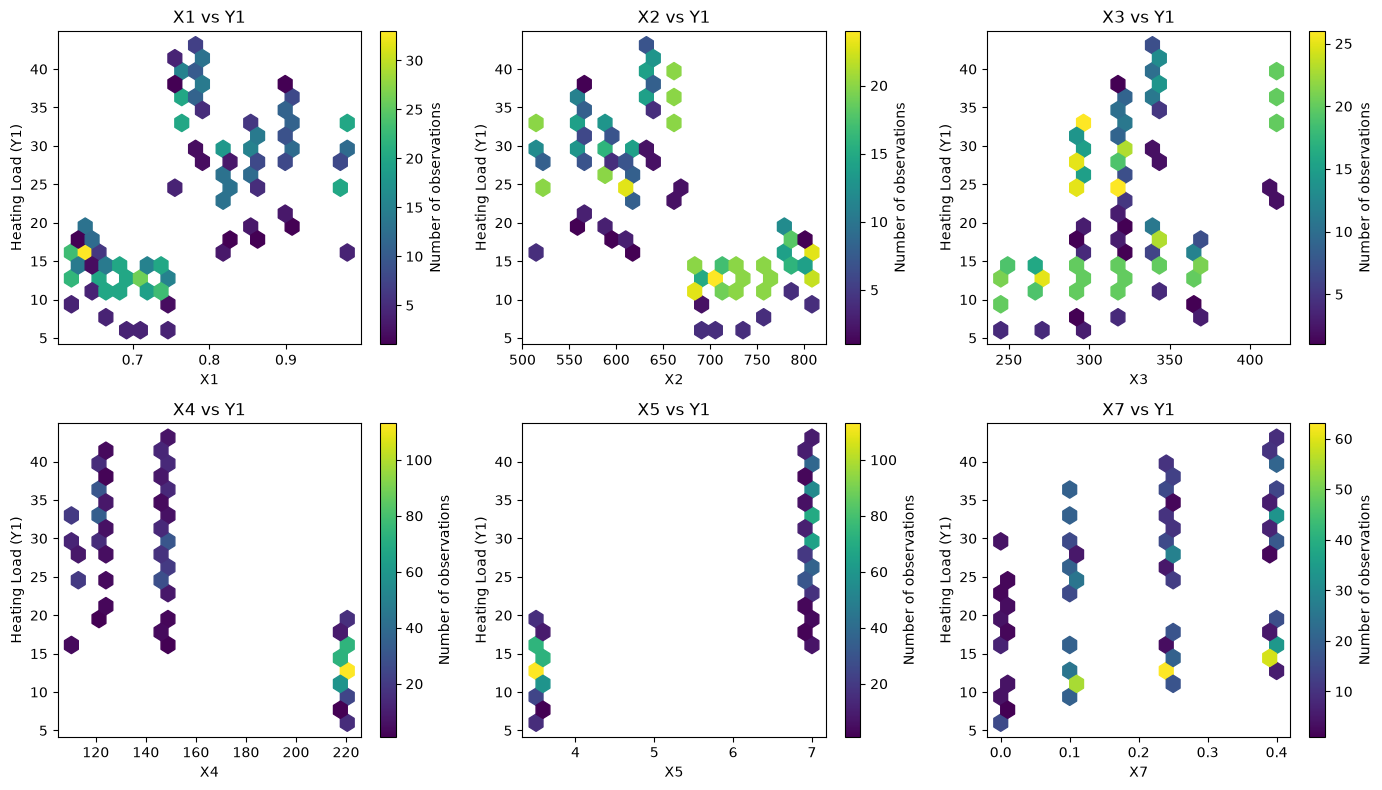

In [16]:
# Hexbin charts to check the relationship between each predictor and the target variable
# A hexbin chart is a two-dimensional histogram that shows the relationship between two variables. It
# is useful for visualizing the density of points in a scatter plot, especially when there are many overlapping points.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, feature in zip(axes, X.columns):
    hex_plot = ax.hexbin(
        X[feature],
        y,
        gridsize=20,
        cmap="viridis",
        mincnt=1
    )

    ax.set_title(f"{feature} vs Y1")
    ax.set_xlabel(feature)
    ax.set_ylabel("Heating Load (Y1)")
    fig.colorbar(hex_plot, ax=ax, label="Number of observations")

plt.tight_layout()
plt.show()

A hexbin plot is appropriate because it reveals both the relationship between a predictor and Heating Load and where observations are concentrated when points overlap.
How to interpret each plot:
- An upward pattern: larger feature values tend to be associated with higher Heating Load.
- A downward pattern: larger feature values tend to be associated with lower Heating Load.
- A curved pattern: the relationship may be non-linear.
- A wide vertical spread at the same X value: that feature alone does not fully explain Heating Load.
- Dense coloured hexagons: many simulated building designs occur in that region.
- Isolated hexagons: potentially uncommon building configurations.

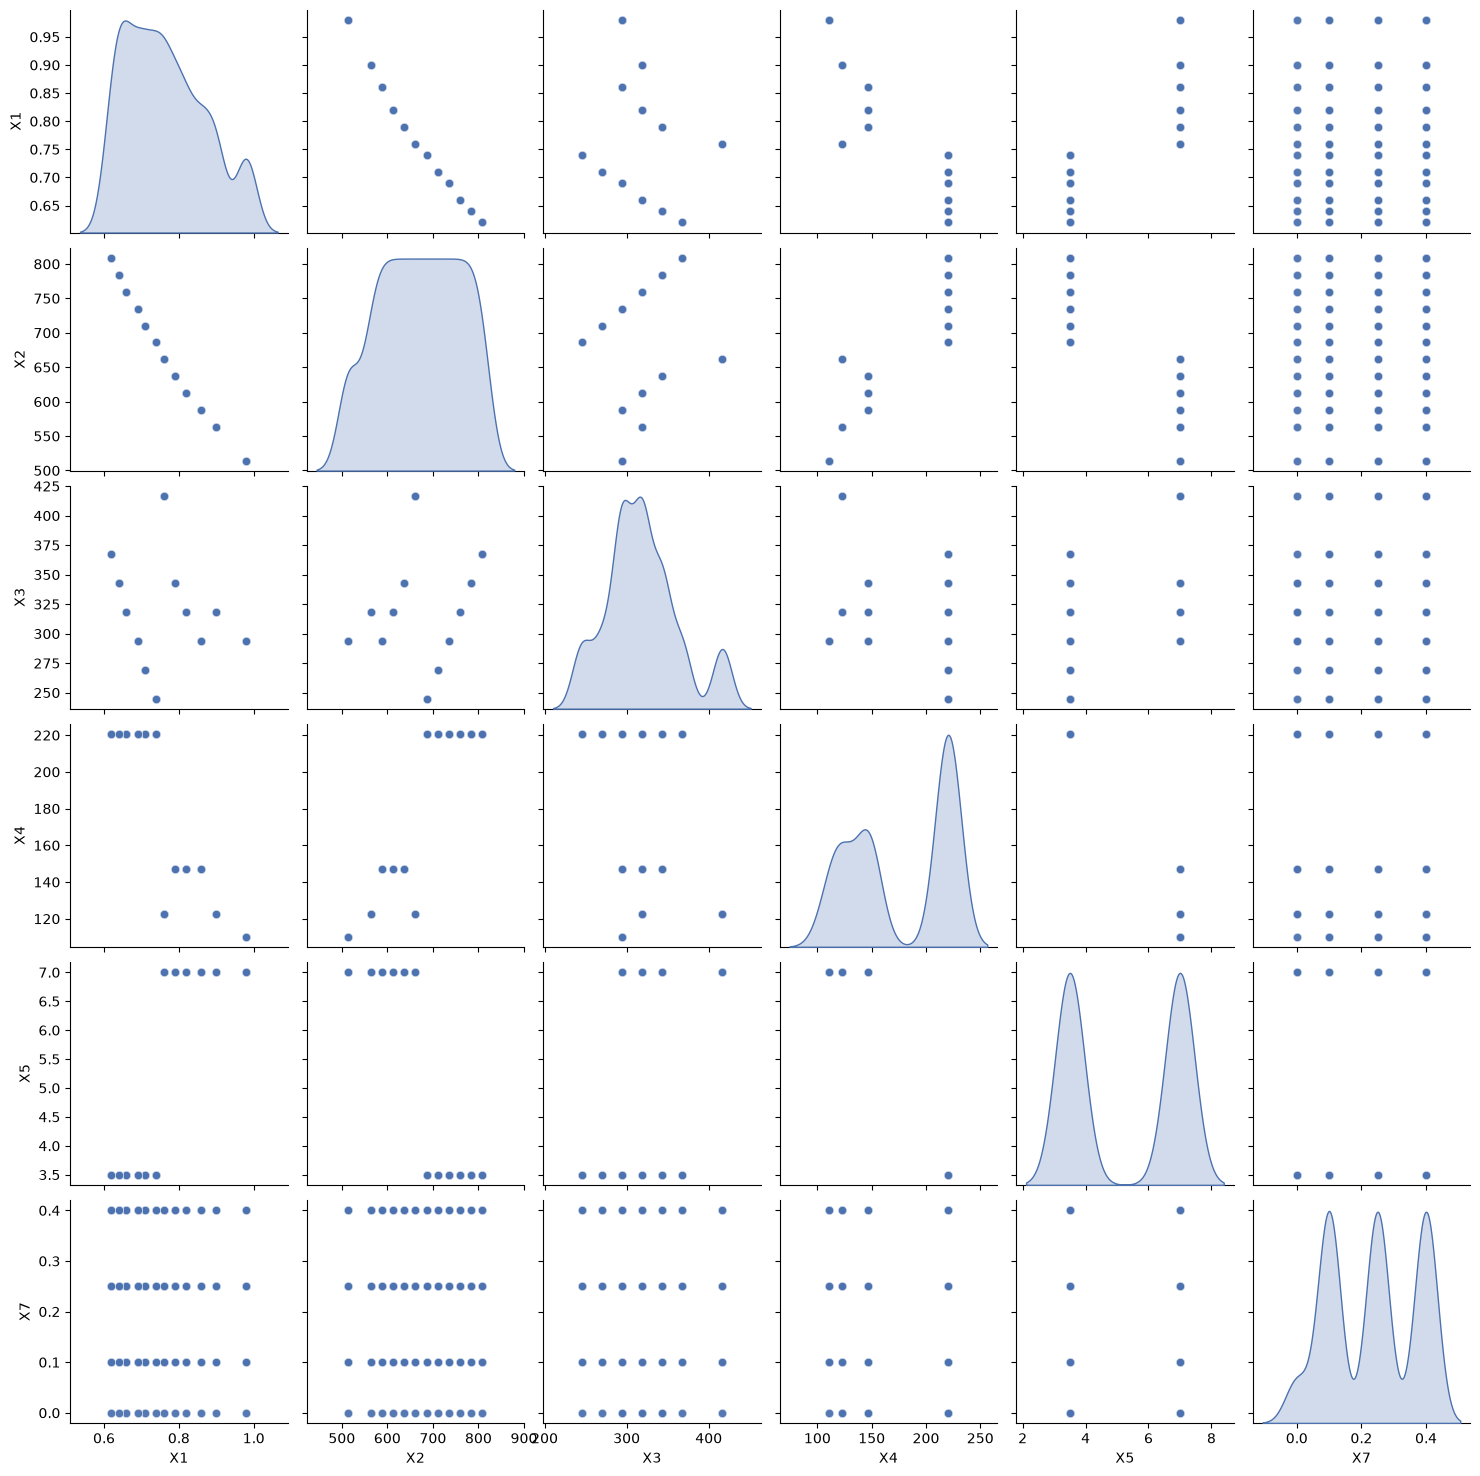

In [17]:
# Pairplot to check the relationship between each predictor and the target variable
# A pairplot is a grid of scatter plots that shows the relationship between each pair of variables
# in a dataset. It is useful for visualizing the relationships between multiple variables at once.

sns.pairplot(df_quant[X.columns], diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

#### Correlation analysis

Correlation is a number between -1 and 1 that measures the direction and strength of a *linear* relationship. It does not prove causation and can miss curved relationships.

Correlation analysis asks two related questions:
1. Which predictors have a linear association with Heating Load?
2. Which predictors are strongly associated with one another? Strong predictor-to-predictor relationships are a warning sign for collinearity in a linear model.


In [18]:
# Correlation table
corr = df_quant.corr(numeric_only=True)

print("Correlation with Heating Load (Y1):")
print(corr["Y1"].sort_values(ascending=False))

print("\nPredictor-only correlation matrix:")
print(corr.loc[X.columns, X.columns])

Correlation with Heating Load (Y1):
Y1    1.000000
Y2    0.975862
X5    0.889430
X1    0.622272
X3    0.455671
X7    0.269842
X2   -0.658120
X4   -0.861828
Name: Y1, dtype: float64

Predictor-only correlation matrix:
              X1            X2            X3            X4            X5  \
X1  1.000000e+00 -9.919015e-01 -2.037817e-01 -8.688234e-01  8.277473e-01   
X2 -9.919015e-01  1.000000e+00  1.955016e-01  8.807195e-01 -8.581477e-01   
X3 -2.037817e-01  1.955016e-01  1.000000e+00 -2.923165e-01  2.809757e-01   
X4 -8.688234e-01  8.807195e-01 -2.923165e-01  1.000000e+00 -9.725122e-01   
X5  8.277473e-01 -8.581477e-01  2.809757e-01 -9.725122e-01  1.000000e+00   
X7 -2.096261e-15  3.623317e-15 -8.647953e-17 -1.753224e-15 -1.977685e-16   

              X7  
X1 -2.096261e-15  
X2  3.623317e-15  
X3 -8.647953e-17  
X4 -1.753224e-15  
X5 -1.977685e-16  
X7  1.000000e+00  


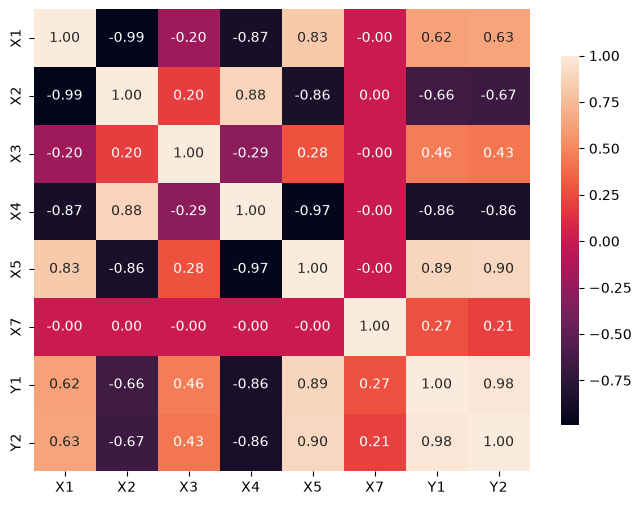

In [19]:
# Heatmap to visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cbar_kws={"shrink": .8})
plt.show()

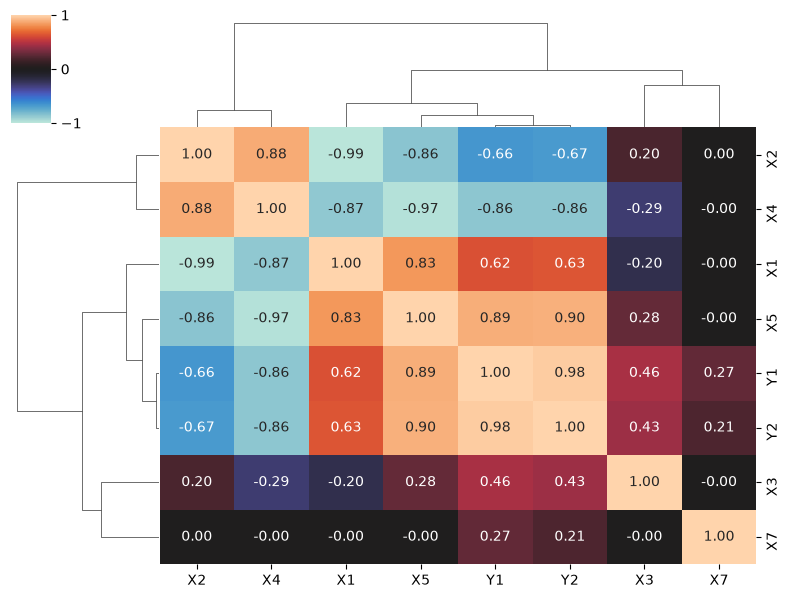

In [20]:
# Clustermap to automatically group variables in above heatmap with similar correlation patterns
sns.clustermap(
    corr,
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    figsize=(8, 6)
)

plt.show()

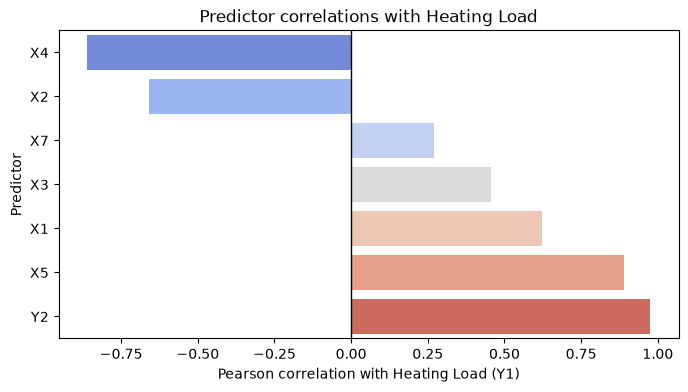

In [21]:
corr_with_y1 = (
    df_quant.corr(numeric_only=True)["Y1"]
    .drop("Y1")
    .sort_values()
)

plt.figure(figsize=(8, 4))
sns.barplot(x=corr_with_y1.values, y=corr_with_y1.index, hue=corr_with_y1.index,
            palette="coolwarm", legend=False)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Pearson correlation with Heating Load (Y1)")
plt.ylabel("Predictor")
plt.title("Predictor correlations with Heating Load")
plt.show()

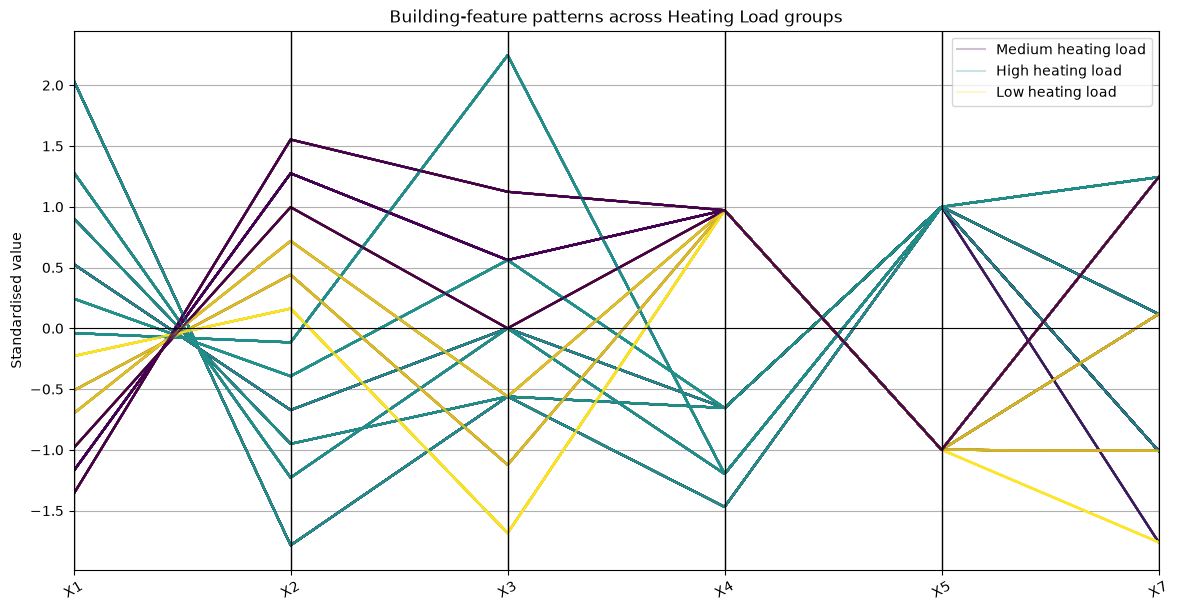

In [22]:
# Parallel-coordinates plot
# A parallel-coordinates plot is not strictly bivariate or purely correlation-based; it is a multivariate chart.
# It lets us compare patterns across all predictors at once.
# Because lines would be impossible to interpret using raw Y1 values,
# we first divide Heating Load into categories such as low, medium, and high.
# Also we have to standardize predictors because they have different units and ranges.

from pandas.plotting import parallel_coordinates

features = list(X.columns)

# Standardise so every feature is on a comparable scale
parallel_df = (df_quant[features] - df_quant[features].mean()) / df_quant[features].std()

# Divide continuous Heating Load into three equally sized groups
parallel_df["Y1_band"] = pd.qcut(
    df_quant["Y1"],
    q=3,
    labels=["Low heating load", "Medium heating load", "High heating load"]
)

plt.figure(figsize=(14, 7))

parallel_coordinates(
    parallel_df,
    class_column="Y1_band",
    colormap="viridis",
    alpha=0.25
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Standardised value")
plt.title("Building-feature patterns across Heating Load groups")
plt.xticks(rotation=30)
plt.show()

A parallel-coordinates plot is appropriate because it compares all predictors simultaneously and helps reveal feature patterns shared by low-, medium-, and high-Heating-Load buildings.

#### Chart choices and what they answer

##### Univariate Analysis
- **Histogram:** A histogram is appropriate for checking each variable's frequency pattern, range, and possible skew.
- **Boxplot:** A boxplot is appropriate for comparing the median and interquartile range and flagging possible outliers.
- **KDE Plot:** A KDE plot is appropriate for showing the smoothed shape and concentration of a distribution without choosing histogram bins. It revealed the shape and concentration of each variable’s distribution
- **ECDF Plot:** An ECDF plot is appropriate for locating medians, quartiles, gaps, and extreme values from the cumulative proportion of observations. This made cumulative spread, quartiles, and possible gaps in the simulated design values clear.
- **Violin Plot:** A violin plot is appropriate for showing spread and density together, including possible multiple peaks.

##### Bivariate Analysis
- **Regression Plot:** A regression plot is appropriate for a first view of the direction and approximate linear trend between each predictor and Heating Load.
- **Hexbin Plot:** A hexbin plot is appropriate for showing both the predictor-Heating Load relationship and where observations are dense when points overlap. This showed the predictor’s relationship with Heating Load while retaining information about observation density.
- **Pairplot:** A pairplot is appropriate for scanning relationships among all quantitative predictors and spotting possible predictor pairs that move together.

##### Correlation Analysis
- **Correlation Heatmap:** A correlation heatmap is appropriate for comparing the direction and strength of all linear associations at once.
- **Correlation Clustermap:** A clustermap is appropriate for grouping variables with similar correlation patterns, which makes potential collinearity easier to see. This quantified linear associations with Y1 and highlighted groups of highly related building-design predictors, which may indicate multicollinearity.
- **Ranked Correlation Bar-chart:** A ranked correlation bar chart is appropriate for comparing every predictor's linear association with Heating Load on one scale.
- **Parallel-coordinates Plot :** A parallel-coordinates plot is appropriate for comparing the full predictor profile of low-, medium-, and high-Heating-Load buildings.

The new chart types I have used here are **KDE plots**, **ECDF plots**, **violin plots**, **hexbin plots**, a **clustermap**, and a **parallel-coordinates plot**. Together, they show distribution shape and cumulative spread, point density, grouped correlation structure, and multivariable feature profiles.

In [23]:
# Numerical evidence used in the findings below
import numpy as np

analysis_columns = list(X.columns) + ["Y1"]
skewness = df_quant[analysis_columns].skew().sort_values(ascending=False)

# The IQR rule flags values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR.
q1 = X.quantile(0.25)
q3 = X.quantile(0.75)
iqr = q3 - q1
outlier_counts = ((X < (q1 - 1.5 * iqr)) | (X > (q3 + 1.5 * iqr))).sum()

corr_with_y1 = df_quant[analysis_columns].corr()["Y1"].drop("Y1").sort_values()
predictor_corr = df_quant[X.columns].corr()
upper_triangle = predictor_corr.where(np.triu(np.ones(predictor_corr.shape), k=1).astype(bool))
high_corr_pairs = upper_triangle.stack().loc[lambda s: s.abs() >= 0.80].sort_values(key=lambda s: s.abs(), ascending=False)

print("Skewness (positive means a longer right tail):")
display(skewness.round(3))
print("IQR outlier counts:")
display(outlier_counts)
print("Pearson correlation with Heating Load (Y1):")
display(corr_with_y1.round(3))
print("Predictor pairs with |correlation| ≥ 0.80:")
display(high_corr_pairs.round(3))

Skewness (positive means a longer right tail):


X3    0.533
X1    0.496
Y1    0.360
X5    0.000
X7   -0.060
X2   -0.125
X4   -0.163
dtype: float64

IQR outlier counts:


X1    0
X2    0
X3    0
X4    0
X5    0
X7    0
dtype: int64

Pearson correlation with Heating Load (Y1):


X4   -0.862
X2   -0.658
X7    0.270
X3    0.456
X1    0.622
X5    0.889
Name: Y1, dtype: float64

Predictor pairs with |correlation| ≥ 0.80:


X1  X2   -0.992
X4  X5   -0.973
X2  X4    0.881
X1  X4   -0.869
X2  X5   -0.858
X1  X5    0.828
dtype: float64

### 3. Findings

- **Overall Height (X5)** has the strongest positive linear association with Heating Load (`r = 0.889`), while **Roof Area (X4)** has the strongest negative association (`r = -0.862`). Surface Area (X2) is also negatively associated (`r = -0.658`), and Relative Compactness (X1) is positively associated (`r = 0.622`). These values come from the ranked correlation chart and correlation table.
- Wall Area (X3) has a moderate positive correlation with Heating Load (`r = 0.456`), while Glazing Area (X7) has a weaker positive correlation (`r = 0.270`).
- The regression and hexbin plots show clear structure but not perfectly straight relationships, particularly for the geometry variables. A linear model can summarise the direction, but the plots should guide whether later modelling needs non-linear terms or a non-linear model.
- The skewness values are small to moderate: Wall Area (`0.533`) and Relative Compactness (`0.496`) have the largest positive skewness among the predictors. The IQR calculation flags zero outliers for every predictor, so the boxplots' isolated-looking values are not IQR outliers.
- There is substantial collinearity among the geometry variables. The strongest pairs are X1 with X2 (`r = -0.992`) and X4 with X5 (`r = -0.973`); X2 with X4 (`r = 0.881`), X1 with X4 (`r = -0.869`), X2 with X5 (`r = -0.858`), and X1 with X5 (`r = 0.828`) are also high. The clustermap and the printed high-correlation pairs support this conclusion.

### 4. Training and Evaluating Multiple Linear Regression Model

In [24]:
# Train-test split
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
train_size = 0.75
test_size = 1 - train_size

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size=test_size, random_state=RANDOM_STATE)

In [25]:
# Training the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-64.91, -0.06, 0.04, -0.05, 4.01, 20.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['X1','X2','X3','X4','X5','X7']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,86.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [26]:
# Evaluating the multiple linear regression model
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics = regression_metrics(y_test, y_test_pred)

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["train", "test"])
metrics_df

,R2,RMSE,MAE
train,0.915034,2.920239,2.023600
test,0.914980,2.989397,2.147063


**Model performance:** 
- The model explains about 91.5% of the variance in Heating Load on both the training set (R² = 0.915) and the test set (R² = 0.915), and the test RMSE (2.99) and MAE (2.15) are close to the training values (2.92 and 2.02), so there is no meaningful over- or under-fitting.
- On the test set, a typical prediction is off by about 2.1–3.0 kWh/m² of Heating Load, which is small relative to the ~10 kWh/m² standard deviation and ~37 kWh/m² range of Y1 in the data.

### 5. Interpreting Model Parameters

In [60]:
# Raw coefficients (in the original units) show the real-world effect of each predictor.
# Standardised coefficients (fit on z-scored predictors) let us compare predictors on one scale.
from sklearn.preprocessing import StandardScaler

coef_table = pd.DataFrame({
    "coefficient": model.coef_,
    "abs_coefficient": np.abs(model.coef_),
}, index=X.columns).sort_values("abs_coefficient", ascending=False)
coef_table["intercept"] = model.intercept_

scaler = StandardScaler().fit(X_train)
model_std = LinearRegression().fit(scaler.transform(X_train), y_train)
coef_table["standardised_coefficient"] = pd.Series(model_std.coef_, index=X.columns)
coef_table = coef_table.sort_values("standardised_coefficient", key=np.abs, ascending=False)
coef_table

,coefficient,abs_coefficient,intercept,standardised_coefficient
X5,4.005591,4.005591,86.248268,7.008728
X1,-64.906521,64.906521,86.248268,-6.842376
X4,-0.051509,0.051509,86.248268,-4.163740
X2,-0.064540,0.064540,86.248268,-3.861953
X7,20.206912,20.206912,86.248268,2.697309
X3,0.038479,0.038479,86.248268,0.762701


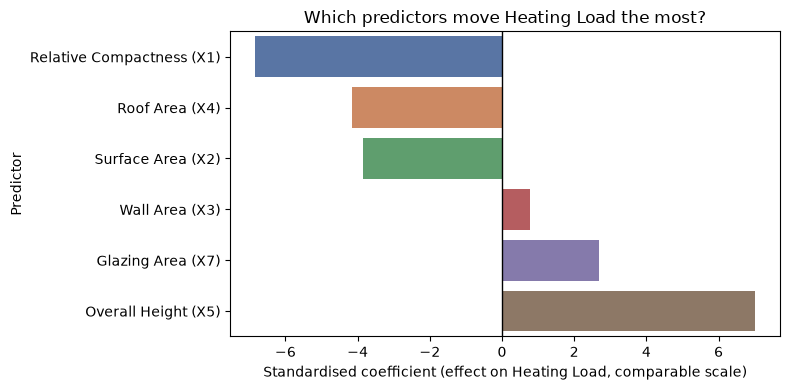

In [61]:
# Bar chart of standardised coefficients, ranked by effect size
feature_names = {
    "X1": "Relative Compactness (X1)",
    "X2": "Surface Area (X2)",
    "X3": "Wall Area (X3)",
    "X4": "Roof Area (X4)",
    "X5": "Overall Height (X5)",
    "X7": "Glazing Area (X7)",
}

plot_data = coef_table.sort_values("standardised_coefficient")
plot_labels = plot_data.index.map(feature_names)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=plot_data["standardised_coefficient"],
    y=plot_labels,
    hue=plot_labels,
    legend=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Standardised coefficient (effect on Heating Load, comparable scale)")
plt.ylabel("Predictor")
plt.title("Which predictors move Heating Load the most?")
plt.tight_layout()
plt.show()

Let's think of the fitted model as a simple rule of thumb: start from a baseline number, then add or subtract for each feature of the building.

**The intercept, about 86.2, is the model's starting point for a building with every predictor at zero:**
Zero relative compactness, zero surface area, zero wall area, zero roof area, zero height, and zero glazing. That building doesn't exist in real life, so the intercept isn't a "real" prediction on its own; it's just the anchor the model adjusts from for every actual building.

**Relative Compactness (X1), coefficient ≈ −64.9:**
Holding everything else fixed, a building that is one full unit "more compact" is predicted to need about 65 kWh/m² less heating. A more compact shape, closer to a cube with less exposed surface per unit of volume, loses less heat, so the negative sign makes physical sense. Caveat: X1 is almost a mirror image of Surface Area in this data (r ≈ −0.99), so the model can't cleanly tell the two apart, and this number is shaky read on its own.

**Surface Area (X2), coefficient ≈ −0.065:**
Each extra m² of outer surface is predicted to lower Heating Load by about 0.065 kWh/m². On its own this looks backwards, since more exposed surface should mean more heat loss, not less. It's the same collinearity problem: surface area, compactness, roof area, and height all move together for these simulated buildings, so one real effect gets split across several correlated variables with confusing individual signs. Surface area was clearly negatively correlated with Heating Load (r ≈ −0.66) before the other variables entered the model, so don't read this coefficient as "surface area doesn't matter."

**Wall Area (X3), coefficient ≈ +0.038:**
Each extra m² of wall area, holding the rest fixed, adds about 0.04 kWh/m² of heating need. More wall means more surface exposed to the outside, so a bit more heat escapes. The effect is small and trustworthy, since wall area is fairly independent of the other geometry variables.

**Roof Area (X4), coefficient ≈ −0.052:**
Each extra m² of roof is predicted to lower Heating Load by about 0.05 kWh/m². This fights intuition on its own for the same reason as surface area: roof area is tightly linked to height and compactness (r ≈ −0.97 with height), so this number is really a mix of effects rather than roof area's true individual contribution.

**Overall Height (X5), coefficient ≈ +4.01:**
Holding the rest fixed, each extra metre of building height adds about 4 kWh/m² to Heating Load. This is the biggest raw-unit effect in the model and matches intuition: taller buildings have more exposed wall and more volume to heat.

**Glazing Area (X7), coefficient ≈ +20.21:**
Going from 0% to 100% glazing would add about 20 kWh/m²; more realistically, going from the data's smallest glazing share (0%) to its largest (40%) adds roughly 20 × 0.4 ≈ 8 kWh/m². Windows lose heat faster than insulated walls, so this makes physical sense. Glazing Area isn't correlated with any geometry variable (all ≈ 0), so unlike the geometry coefficients above, this one is trustworthy on its own.

X1, X2, X3, X4, X5, and X7 are all measured in different units (a ratio, three separate m² areas, metres, and a fraction), so comparing raw coefficients means comparing apples to oranges. Standardising every predictor first and refitting gives a fair ranking of effect size: Overall Height (X5) first, then Relative Compactness (X1), then Roof Area (X4) and Surface Area (X2), then Glazing Area (X7), with Wall Area (X3) smallest. Shape and height dominate, glazing has a real but smaller effect, and wall area barely moves the needle once the rest is accounted for.

**For an architect, the takeaway is: make the building shorter and more compact, keep glazing modest, and Heating Load drops.** Don't trust the individual signs on Surface Area or Roof Area in isolation; they're so entangled with height and compactness in this dataset that the model can't cleanly separate them. Shape and height together are the real driver, not any single geometry coefficient.